In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

pd.set_option("display.max_columns", None)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

Dispositivo: cuda


In [2]:
RUTA_CSV = "../data/csv/df_merged.csv"

df_raw = pd.read_csv(RUTA_CSV, parse_dates=["date"], index_col="date")
df_raw.sort_index(inplace=True)

df_raw.head()

,btc_open,btc_high,btc_low,btc_close,btc_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,btc_dominance,eth_dominance,alt_dominance,fear_greed,FearGreed_Label,inflation,btc_mcap,eth_mcap,fed_rate
date,,,,,,,,,,,,,,,,,,,
2018-02-01,10237.299805,10288.799805,8812.280273,9170.540039,9959400448,1119.369995,1161.349976,984.818970,1036.790039,5261680128,0.334251,0.211308,0.454441,30.0,Fear,2.263469,1.703042e+11,1.076635e+11,1.42
2018-02-02,9142.280273,9142.280273,7796.490234,8830.750000,12726899712,1035.770020,1035.770020,757.979980,915.784973,6713290240,0.339622,0.221066,0.439312,15.0,Extreme Fear,2.263469,1.527442e+11,9.942376e+10,1.42
2018-02-03,8852.120117,9430.750000,8251.629883,9174.910156,7263790080,919.210999,991.942993,847.690002,964.018982,3243480064,0.350252,0.209758,0.439990,40.0,Fear,2.263469,1.487152e+11,8.906186e+10,1.42
2018-02-04,9175.700195,9334.870117,8031.220215,8277.009766,7073549824,964.666992,969.031982,805.064026,834.682007,2997090048,0.341270,0.206612,0.452118,24.0,Extreme Fear,2.263469,1.515073e+11,9.172561e+10,1.42
2018-02-05,8270.540039,8364.839844,6756.680176,6955.270020,9285289984,834.958008,856.645996,644.598999,697.950989,4269530112,0.351816,0.204261,0.443923,11.0,Extreme Fear,2.263469,1.400815e+11,8.132982e+10,1.42


In [3]:

# OHE de FearGreed_Label
if "FearGreed_Label" in df_raw.columns:
    ohe = pd.get_dummies(df_raw["FearGreed_Label"], prefix="fng", dtype=int)
    ohe.columns = [c.replace(" ", "_") for c in ohe.columns]
    df_raw = df_raw.drop(columns=["FearGreed_Label"]).join(ohe)

OHE_COLS = [c for c in df_raw.columns
            if c.startswith("fng_") and c != "fng_scaled"]

print(f"Shape raw: {df_raw.shape}")
print(f"Rango: {df_raw.index.min().date()} → {df_raw.index.max().date()}")
print(f"OHE cols: {OHE_COLS}")

Shape raw: (2885, 23)
Rango: 2018-02-01 → 2025-12-25
OHE cols: ['fng_Extreme_Fear', 'fng_Extreme_Greed', 'fng_Fear', 'fng_Greed', 'fng_Neutral']


In [4]:
df_raw.head()

,btc_open,btc_high,btc_low,btc_close,btc_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,btc_dominance,eth_dominance,alt_dominance,fear_greed,inflation,btc_mcap,eth_mcap,fed_rate,fng_Extreme_Fear,fng_Extreme_Greed,fng_Fear,fng_Greed,fng_Neutral
date,,,,,,,,,,,,,,,,,,,,,,,
2018-02-01,10237.299805,10288.799805,8812.280273,9170.540039,9959400448,1119.369995,1161.349976,984.818970,1036.790039,5261680128,0.334251,0.211308,0.454441,30.0,2.263469,1.703042e+11,1.076635e+11,1.42,0,0,1,0,0
2018-02-02,9142.280273,9142.280273,7796.490234,8830.750000,12726899712,1035.770020,1035.770020,757.979980,915.784973,6713290240,0.339622,0.221066,0.439312,15.0,2.263469,1.527442e+11,9.942376e+10,1.42,1,0,0,0,0
2018-02-03,8852.120117,9430.750000,8251.629883,9174.910156,7263790080,919.210999,991.942993,847.690002,964.018982,3243480064,0.350252,0.209758,0.439990,40.0,2.263469,1.487152e+11,8.906186e+10,1.42,0,0,1,0,0
2018-02-04,9175.700195,9334.870117,8031.220215,8277.009766,7073549824,964.666992,969.031982,805.064026,834.682007,2997090048,0.341270,0.206612,0.452118,24.0,2.263469,1.515073e+11,9.172561e+10,1.42,1,0,0,0,0
2018-02-05,8270.540039,8364.839844,6756.680176,6955.270020,9285289984,834.958008,856.645996,644.598999,697.950989,4269530112,0.351816,0.204261,0.443923,11.0,2.263469,1.400815e+11,8.132982e+10,1.42,1,0,0,0,0


In [5]:
df = df_raw.copy()

# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE A — Retornos porcentuales (precios y volúmenes)
# Fórmula: ret_t = (precio_t - precio_{t-1}) / precio_{t-1} × 100
# Por qué: los precios son no estacionarios (crecen sin límite).
# El retorno % sí es estacionario: oscila alrededor de 0.
# ══════════════════════════════════════════════════════════════════════════════
for col in ["btc_open","btc_high","btc_low","btc_close","btc_volume",
            "eth_open","eth_high","eth_low","eth_close","eth_volume",
            "btc_mcap","eth_mcap"]:
    if col in df.columns:
        df[f"{col}_ret"] = df[col].pct_change() * 100

# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE B — Diferencias en puntos porcentuales (dominancias)
# Fórmula: diff_t = valor_t - valor_{t-1}
# Por qué: las dominancias ya son porcentajes (ej. BTC domina 45% del mercado).
# No tiene sentido calcular "el % de cambio de un %". Lo que importa es
# si BTC ganó o perdió cuota: +1.2 significa que ganó 1.2 puntos porcentuales.
# ══════════════════════════════════════════════════════════════════════════════
for col in ["btc_dominance","eth_dominance","alt_dominance"]:
    if col in df.columns:
        df[f"{col}_diff"] = df[col].diff()

# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE C — Volatilidad realizada (7 y 14 días)
# Fórmula: vol_t = std(eth_close_ret_{t-w : t}) × sqrt(w)
# Por qué: la desviación estándar de los retornos recientes mide cuánto
# "oscila" el mercado. Multiplicar por sqrt(w) la anualiza a la ventana
# (convención financiera). Valores altos = mercado nervioso.
# ══════════════════════════════════════════════════════════════════════════════
for w in [7, 14]:
    df[f"eth_vol_realizada_{w}d"] = (
        df["eth_close_ret"].rolling(w).std() * np.sqrt(w)
    )
    df[f"btc_vol_realizada_{w}d"] = (
        df["btc_close_ret"].rolling(w).std() * np.sqrt(w)
    )

# ══════════════════════════════════════════════════════════════════════════════
# BLOQUE D — Macro: valor absoluto (NO transformar)
# Fórmula: se quedan tal cual (inflation, fed_rate)
# Por qué: ya son porcentajes acotados que no crecen indefinidamente.
# El nivel importa: saber que los tipos están al 5.25% vs 0.25%
# es muy informativo para el modelo. No necesitan diferenciarse.
# ══════════════════════════════════════════════════════════════════════════════
# (inflation y fed_rate ya están en df, no hay que hacer nada)

# ── Limpiar columnas originales no estacionarias ─────────────────────────────
COLS_DROP = ["btc_open","btc_high","btc_low","btc_close","btc_volume",
             "eth_open","eth_high","eth_low","eth_close","eth_volume",
             "btc_mcap","eth_mcap",
             "btc_dominance","eth_dominance","alt_dominance"]
df = df.drop(columns=[c for c in COLS_DROP if c in df.columns])
df = df.dropna()

print(f"Shape tras transformaciones: {df.shape}")
print(f"Columnas ({len(df.columns)}):\n{df.columns.tolist()}")

Shape tras transformaciones: (2871, 27)
Columnas (27):
['fear_greed', 'inflation', 'fed_rate', 'fng_Extreme_Fear', 'fng_Extreme_Greed', 'fng_Fear', 'fng_Greed', 'fng_Neutral', 'btc_open_ret', 'btc_high_ret', 'btc_low_ret', 'btc_close_ret', 'btc_volume_ret', 'eth_open_ret', 'eth_high_ret', 'eth_low_ret', 'eth_close_ret', 'eth_volume_ret', 'btc_mcap_ret', 'eth_mcap_ret', 'btc_dominance_diff', 'eth_dominance_diff', 'alt_dominance_diff', 'eth_vol_realizada_7d', 'btc_vol_realizada_7d', 'eth_vol_realizada_14d', 'btc_vol_realizada_14d']


In [ ]:
def add_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ══════════════════════════════════════════════════════════════════════════
    # SENTIMIENTO ACUMULADO — ventanas 15 y 30 días
    # Fórmula: sum(ohe_col, ventana)
    # Resultado: "en los últimos 15 días, ¿cuántos fueron de miedo extremo?"
    # Un valor de 12/15 en Extreme_Fear es una señal muy potente de capitulación.
    # La asimetría 15 vs 30 detecta si el miedo se está acelerando recientemente
    # (15d > 30d/2) o si viene de antes pero se está calmando (15d < 30d/2).
    # ══════════════════════════════════════════════════════════════════════════
    for w in [15, 30]:
        for col in OHE_COLS:
            if col in df.columns:
                df[f"{col}_sum{w}d"] = df[col].rolling(w).sum()

        # Ratio miedo vs codicia en la ventana
        fear_cols  = [c for c in OHE_COLS if "Fear"  in c and c in df.columns]
        greed_cols = [c for c in OHE_COLS if "Greed" in c and c in df.columns]
        if fear_cols and greed_cols:
            fear_sum  = sum(df[c].rolling(w).sum() for c in fear_cols)
            greed_sum = sum(df[c].rolling(w).sum() for c in greed_cols)
            df[f"fear_greed_ratio_{w}d"] = fear_sum / (greed_sum + 1e-8)
            # >1 predomina miedo, <1 predomina codicia

        # Retorno acumulado de la ventana (¿venimos de tendencia alcista?)
        if "eth_close_ret" in df.columns:
            df[f"eth_cum_ret_{w}d"] = df["eth_close_ret"].rolling(w).sum().shift(1)


    # ══════════════════════════════════════════════════════════════════════════
    # VOLATILIDAD EN CONTEXTO — ventanas 7 y 14 días
    # Fórmula días de movimiento brusco: sum(|ret| > std_global, ventana)
    # Resultado: "en los últimos 7 días, ¿cuántos tuvieron un movimiento > 1σ?"
    # Complementa la volatilidad realizada (que mide magnitud) con
    # la frecuencia de eventos extremos (que mide nerviosismo del mercado).
    # ══════════════════════════════════════════════════════════════════════════
    std_global = df["eth_close_ret"].std()   # umbral global fijo

    for w in [7, 14]:
        df[f"eth_big_moves_{w}d"] = (
            (df["eth_close_ret"].abs() > std_global)
            .rolling(w).sum()
        )
        # Media de indicadores técnicos en la ventana
        for col in ["rsi_14","adx_14","bb_width","atr_pct","macd_hist"]:
            if col in df.columns:
                df[f"{col}_mean{w}d"] = df[col].rolling(w).mean()
                df[f"{col}_std{w}d"]  = df[col].rolling(w).std()

        # Presión acumulada de dominancias
        for col in ["btc_dominance_diff","eth_dominance_diff"]:
            if col in df.columns:
                df[f"{col}_sum{w}d"] = df[col].rolling(w).sum()

    return df.dropna()


df = add_rolling_features(df)

print(f"Shape final con rolling features: {df.shape}")
print(f"Total features: {len(df.columns)}")

# ── Vista rápida de las features nuevas más interesantes ─────────────────────
cols_sentimiento = [c for c in df.columns if "sum15d" in c or "sum30d" in c
                    or "fear_greed_ratio" in c]
cols_volatilidad = [c for c in df.columns if "vol_realizada" in c
                    or "big_moves" in c]

print(f"\nFeatures de sentimiento ({len(cols_sentimiento)}): {cols_sentimiento}")
print(f"\nFeatures de volatilidad ({len(cols_volatilidad)}): {cols_volatilidad}")
print(f"\nMuestra de datos recientes:")
print(df[cols_sentimiento + cols_volatilidad].tail(5).round(3).to_string())

Shape final con rolling features: (2842, 47)
Total features: 47

Features de sentimiento (12): ['fng_Extreme_Fear_sum15d', 'fng_Extreme_Greed_sum15d', 'fng_Fear_sum15d', 'fng_Greed_sum15d', 'fng_Neutral_sum15d', 'fear_greed_ratio_15d', 'fng_Extreme_Fear_sum30d', 'fng_Extreme_Greed_sum30d', 'fng_Fear_sum30d', 'fng_Greed_sum30d', 'fng_Neutral_sum30d', 'fear_greed_ratio_30d']

Features de volatilidad (6): ['eth_vol_realizada_7d', 'btc_vol_realizada_7d', 'eth_vol_realizada_14d', 'btc_vol_realizada_14d', 'eth_big_moves_7d', 'eth_big_moves_14d']

Muestra de datos recientes:
            fng_Extreme_Fear_sum15d  fng_Extreme_Greed_sum15d  fng_Fear_sum15d  fng_Greed_sum15d  fng_Neutral_sum15d  fear_greed_ratio_15d  fng_Extreme_Fear_sum30d  fng_Extreme_Greed_sum30d  fng_Fear_sum30d  fng_Greed_sum30d  fng_Neutral_sum30d  fear_greed_ratio_30d  eth_vol_realizada_7d  btc_vol_realizada_7d  eth_vol_realizada_14d  btc_vol_realizada_14d  eth_big_moves_7d  eth_big_moves_14d
date                           

In [7]:
df.head()

,fear_greed,inflation,fed_rate,fng_Extreme_Fear,fng_Extreme_Greed,fng_Fear,fng_Greed,fng_Neutral,btc_open_ret,btc_high_ret,btc_low_ret,btc_close_ret,btc_volume_ret,eth_open_ret,eth_high_ret,eth_low_ret,eth_close_ret,eth_volume_ret,btc_mcap_ret,eth_mcap_ret,btc_dominance_diff,eth_dominance_diff,alt_dominance_diff,eth_vol_realizada_7d,btc_vol_realizada_7d,eth_vol_realizada_14d,btc_vol_realizada_14d,fng_Extreme_Fear_sum15d,fng_Extreme_Greed_sum15d,fng_Fear_sum15d,fng_Greed_sum15d,fng_Neutral_sum15d,fear_greed_ratio_15d,eth_cum_ret_15d,fng_Extreme_Fear_sum30d,fng_Extreme_Greed_sum30d,fng_Fear_sum30d,fng_Greed_sum30d,fng_Neutral_sum30d,fear_greed_ratio_30d,eth_cum_ret_30d,eth_big_moves_7d,btc_dominance_diff_sum7d,eth_dominance_diff_sum7d,eth_big_moves_14d,btc_dominance_diff_sum14d,eth_dominance_diff_sum14d
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-03-16,33.0,2.33095,1.51,0,0,1,0,0,0.387786,1.860397,2.855696,0.451631,-22.606861,-0.497850,0.411205,1.442092,-1.576630,-19.944535,0.637709,0.686682,0.002083,0.000973,-0.003056,13.320392,14.960995,16.571509,18.181738,0.0,0.0,11.0,3.0,1.0,3.666667,-35.357271,0.0,0.0,19.0,9.0,2.0,2.111111,-40.155911,3.0,0.004720,-0.000192,5.0,0.021606,-0.003507
2018-03-17,31.0,2.33095,1.51,0,0,1,0,0,-0.012015,-2.779452,-2.404532,-5.054594,-16.320060,-1.650932,-2.249318,-6.594403,-8.125276,-10.550673,1.933608,-0.724749,0.003504,-0.003258,-0.000245,14.159094,14.962269,17.272975,17.389726,0.0,0.0,12.0,3.0,0.0,4.000000,-41.722975,0.0,0.0,20.0,8.0,2.0,2.500000,-49.733721,3.0,0.014285,-0.006662,6.0,0.018370,-0.004717
2018-03-18,29.0,2.33095,1.51,0,0,1,0,0,-5.183787,-1.210329,-5.309601,3.875262,49.999213,-8.316403,-9.441171,-16.209915,-2.557082,111.821945,-5.348718,-7.839329,0.006528,-0.002033,-0.004495,10.546367,12.202104,16.719474,18.370467,0.0,0.0,13.0,2.0,0.0,6.500000,-44.323465,0.0,0.0,21.0,7.0,2.0,3.000000,-53.062862,2.0,0.021075,-0.009565,6.0,0.016792,-0.004828
2018-03-19,29.0,2.33095,1.51,0,0,1,0,0,5.748672,5.219330,10.603010,4.948766,1.354382,-0.908933,1.171046,12.831235,3.356954,-23.783650,1.927196,-3.803275,0.007717,-0.006918,-0.000800,12.931905,13.755592,17.927089,19.585145,0.0,0.0,13.0,2.0,0.0,6.500000,-42.069256,0.0,0.0,22.0,6.0,2.0,3.666667,-52.873103,2.0,0.025104,-0.013156,6.0,0.029635,-0.010541
2018-03-20,37.0,2.33095,1.51,0,0,1,0,0,3.302323,4.324055,2.535805,3.276918,-5.458672,1.846968,1.610832,0.400867,0.080646,-10.411914,5.155701,3.063314,-0.005589,-0.005435,0.011024,13.225475,14.356653,18.092273,19.470109,0.0,0.0,14.0,1.0,0.0,14.000000,-40.489327,0.0,0.0,23.0,5.0,2.0,4.600000,-47.639680,2.0,0.019423,-0.019458,6.0,0.016403,-0.014754


In [8]:
# ── Cell 4b: correlación predictiva (feature[t] vs target[t+lag]) ─────────────
TARGET   = "eth_close_ret"
features = [c for c in df.columns if c != TARGET]

resultados = []
for lag in [1, 2, 3]:
    target_lag = df[TARGET].shift(-lag)
    for col in features:
        resultados.append({
            "feature":  col,
            "lag":      lag,
            "corr":     df[col].corr(target_lag),
        })

df_corr = pd.DataFrame(resultados)
df_corr["corr_abs"] = df_corr["corr"].abs()

# Top 10 por cada lag
for lag in [1, 2, 3]:
    print(f"\n══ TOP 10 predictivas para +{lag} día(s) ══")
    top = (df_corr[df_corr["lag"] == lag]
           .sort_values("corr_abs", ascending=False).head(10))
    for _, row in top.iterrows():
        signo = "▲" if row["corr"] > 0 else "▼"
        print(f"  {signo} {row['feature']:<42s} {row['corr']:+.4f}")

# ── Cell 5: filtrar por umbral sobre la media de los 3 lags ──────────────────
UMBRAL = 0.02   # solo eliminamos ruido puro

corr_max = df_corr.groupby("feature")["corr_abs"].max()   # máximo entre lags

cols_ruido    = corr_max[corr_max <  UMBRAL].index.tolist()
FEATURE_COLS  = corr_max[corr_max >= UMBRAL].index.tolist()

# Aseguramos que el target no esté en features
FEATURE_COLS = [c for c in FEATURE_COLS if c != TARGET]

print(f"\n══ Resultado del filtro (umbral max|corr| >= {UMBRAL}) ══")
print(f"  Features conservadas : {len(FEATURE_COLS)}")
print(f"  Features eliminadas  : {len(cols_ruido)}")
print(f"  Eliminadas           : {cols_ruido}")

df_model = df[FEATURE_COLS + [TARGET]].copy()
print(f"\nShape final df_model: {df_model.shape}")
print(f"Columnas:\n{FEATURE_COLS}")


══ TOP 10 predictivas para +1 día(s) ══
  ▼ btc_close_ret                              -0.0576
  ▲ eth_mcap_ret                               +0.0529
  ▼ fng_Fear_sum15d                            -0.0526
  ▲ fear_greed                                 +0.0526
  ▲ eth_open_ret                               +0.0524
  ▼ fng_Fear_sum30d                            -0.0482
  ▼ fng_Fear                                   -0.0472
  ▲ btc_mcap_ret                               +0.0466
  ▲ fng_Greed                                  +0.0464
  ▲ btc_open_ret                               +0.0434

══ TOP 10 predictivas para +2 día(s) ══
  ▲ fng_Extreme_Greed                          +0.0543
  ▲ eth_volume_ret                             +0.0528
  ▼ fng_Fear_sum15d                            -0.0504
  ▲ fear_greed                                 +0.0490
  ▼ fng_Fear_sum30d                            -0.0449
  ▲ btc_close_ret                              +0.0436
  ▲ eth_cum_ret_15d                   

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 5 — Target, parámetros globales y normalización
# ══════════════════════════════════════════════════════════════════════════════
TARGET_COL   = "eth_close_ret"
SEQ_LEN      = 30
HORIZON      = 3

# Lo que debería ser:
split_rows = int(len(df_model) * 0.9)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit SOLO con train, transform a ambos
data_X_train = scaler_X.fit_transform(df_model[FEATURE_COLS].iloc[:split_rows])
data_X_test  = scaler_X.transform(df_model[FEATURE_COLS].iloc[split_rows:])

data_y_train = scaler_y.fit_transform(df_model[[TARGET_COL]].iloc[:split_rows])
data_y_test  = scaler_y.transform(df_model[[TARGET_COL]].iloc[split_rows:])

Features  : 32
Muestras  : 2842
SEQ_LEN   : 30 días  |  HORIZON: 3 días


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 6 — Secuencias MIMO (deslizamiento ×1 para train, split temporal)
# ══════════════════════════════════════════════════════════════════════════════
X_all, y_all = [], []
for i in range(SEQ_LEN, len(data_X) - HORIZON + 1):
    X_all.append(data_X[i - SEQ_LEN : i])
    y_all.append(data_y[i : i + HORIZON].squeeze())

X_all = np.array(X_all)   # (N, SEQ_LEN, n_features)
y_all = np.array(y_all)   # (N, HORIZON)

split   = int(len(X_all) * 0.9)
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

print(f"Total secuencias : {len(X_all)}")
print(f"X_train          : {X_train.shape}  →  {X_train.shape[0]} ventanas")
print(f"X_test           : {X_test.shape}   →  {X_test.shape[0]} ventanas")
print(f"Batches/época    : {X_train.shape[0] // 32}")

Total secuencias : 2810
X_train          : (2529, 30, 32)  →  2529 ventanas
X_test           : (281, 30, 32)   →  281 ventanas
Batches/época    : 79


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 7 — Modelos: LSTM y Transformer (misma interfaz, mismo output)
# ══════════════════════════════════════════════════════════════════════════════

class StackedLSTM(nn.Module):
    def __init__(self, n_features, hidden=[64, 32], dropout=0.3, horizon=3):
        super().__init__()
        self.lstms = nn.ModuleList()
        in_size = n_features
        for h in hidden:
            self.lstms.append(
                nn.LSTM(in_size, h, num_layers=1, batch_first=True)
            )
            in_size = h
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden[-1], hidden[-1] // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden[-1] // 2, horizon)
        )

    def forward(self, x):
        for i, lstm in enumerate(self.lstms):
            x, _ = lstm(x)
            if i < len(self.lstms) - 1:
                x = self.dropout(x)
        return self.fc(x[:, -1, :])


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=500):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class CryptoTransformer(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4,
                 num_layers=2, dropout=0.2, horizon=3):
        super().__init__()
        self.input_proj  = nn.Linear(n_features, d_model)
        self.pos_enc     = PositionalEncoding(d_model, dropout)
        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer,
                                                  num_layers=num_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, horizon)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.transformer(x)
        return self.fc(x[:, -1, :])


# ── Instanciar según MODEL_TYPE ───────────────────────────────────────────────
MODEL_TYPE = "transformer"   # cambia a "lstm" para comparar

n_features = X_train.shape[2]

if MODEL_TYPE == "lstm":
    model = StackedLSTM(n_features, hidden=[64, 32],
                        dropout=0.3, horizon=HORIZON).to(DEVICE)
else:
    model = CryptoTransformer(n_features, d_model=64, nhead=4,
                               num_layers=2, dropout=0.2,
                               horizon=HORIZON).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Modelo     : {MODEL_TYPE.upper()}")
print(f"n_features : {n_features}")
print(f"Parámetros : {n_params:,}")

Modelo     : TRANSFORMER
n_features : 32
Parámetros : 104,259


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 8 — Entrenamiento con early stopping y scheduler
# ══════════════════════════════════════════════════════════════════════════════
BATCH_SIZE = 32
EPOCHS     = 500
LR         = 1e-3
PATIENCE   = 60

class CryptoDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self):        return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(CryptoDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(CryptoDataset(X_test,  y_test),
                          batch_size=BATCH_SIZE, shuffle=False)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.6, patience=20, min_lr=1e-6)

def dir_acc(real, pred):
    return np.mean(np.sign(real) == np.sign(pred)) * 100

train_losses, val_losses = [], []
best_val, no_improve, best_state = float("inf"), 0, None

for epoch in range(1, EPOCHS + 1):
    model.train()
    loss_sum = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        loss_sum += loss.item() * len(y_b)
    train_losses.append(loss_sum / len(X_train))

    model.eval()
    loss_sum, preds_e, reals_e = 0.0, [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            out = model(X_b)
            loss_sum += criterion(out, y_b).item() * len(y_b)
            preds_e.append(out.cpu().numpy())
            reals_e.append(y_b.cpu().numpy())

    val_loss = loss_sum / len(X_test)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val, no_improve = val_loss, 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping época {epoch}")
            break

    if epoch % 25 == 0:
        p = np.concatenate(preds_e)   # (N_test, 3)
        r = np.concatenate(reals_e)
        da1 = dir_acc(r[:, 0], p[:, 0])
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"Época {epoch:4d} | train={train_losses[-1]:.5f}  "
              f"val={val_loss:.5f} | DirAcc+1d={da1:.1f}%  lr={lr_now:.1e}")

model.load_state_dict(best_state)
print(f"\nMejor val_loss: {best_val:.6f}")

Época   25 | train=0.00477  val=0.00327 | DirAcc+1d=100.0%  lr=1.0e-03
Época   50 | train=0.00418  val=0.00326 | DirAcc+1d=100.0%  lr=6.0e-04
Época   75 | train=0.00416  val=0.00326 | DirAcc+1d=100.0%  lr=3.6e-04
Early stopping época 80

Mejor val_loss: 0.003254


══ TRANSFORMER — Evaluación con averaging ══
Días evaluados : 283
MAE            : 2.6834%
RMSE           : 3.8881%
MAPE           : 1389.17%
DirAcc         : 50.9%   (baseline 50.0%)


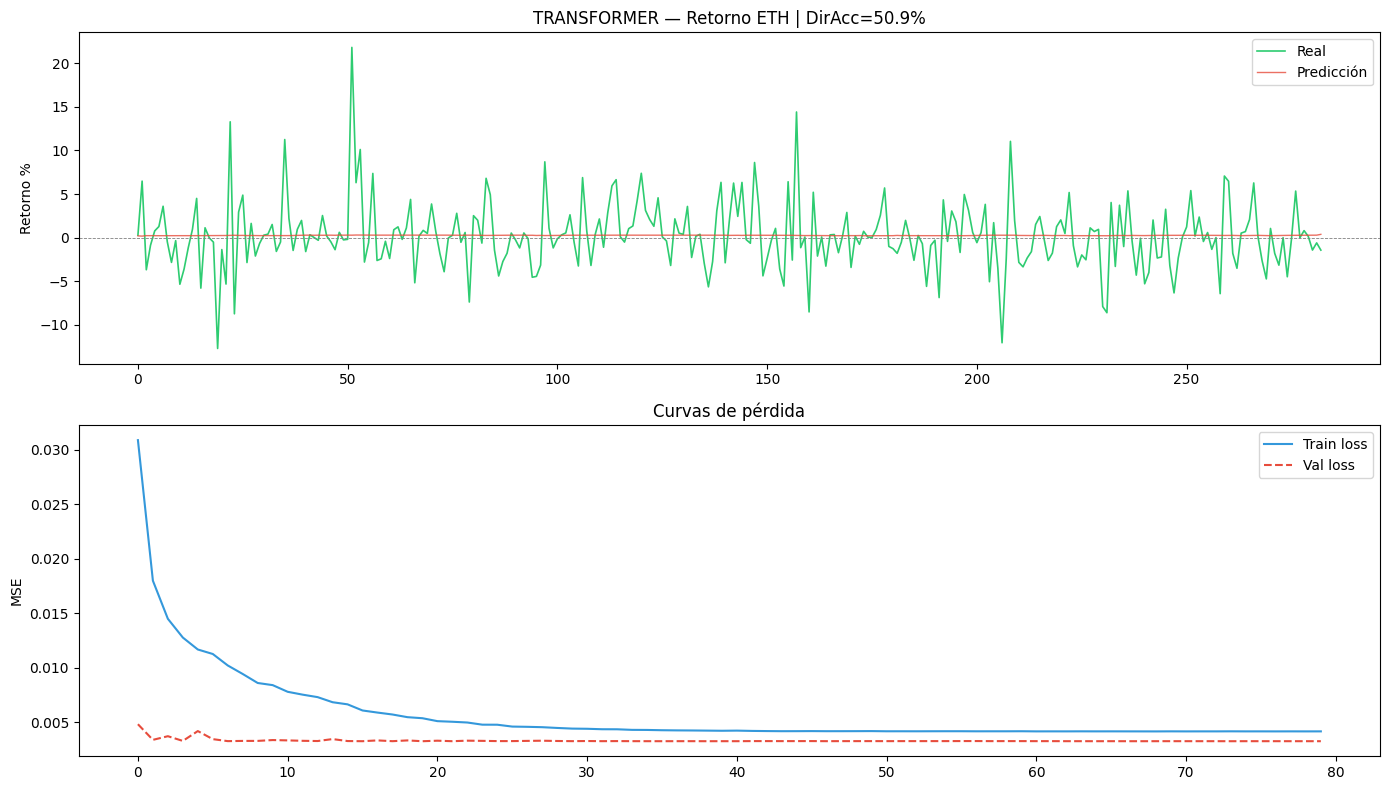

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 9 — Evaluación con averaging (cada día predicho múltiples veces)
# ══════════════════════════════════════════════════════════════════════════════
model.eval()
split_idx = split + SEQ_LEN   # primer índice real de test en data_X

preds_por_dia  = defaultdict(list)
reales_por_dia = {}

with torch.no_grad():
    for i in range(split_idx, len(data_X) - HORIZON + 1):
        x   = torch.FloatTensor(data_X[i - SEQ_LEN : i]).unsqueeze(0).to(DEVICE)
        pred = model(x).cpu().numpy().squeeze()
        for h in range(HORIZON):
            preds_por_dia[i + h].append(pred[h])
            reales_por_dia[i + h] = data_y[i + h, 0]

dias        = sorted(preds_por_dia.keys())
preds_avg   = np.array([np.mean(preds_por_dia[d]) for d in dias])
reales      = np.array([reales_por_dia[d]          for d in dias])

preds_real  = scaler_y.inverse_transform(preds_avg.reshape(-1, 1)).squeeze()
reales_real = scaler_y.inverse_transform(reales.reshape(-1, 1)).squeeze()

mae   = np.mean(np.abs(preds_real - reales_real))
rmse  = np.sqrt(np.mean((preds_real - reales_real) ** 2))
mape  = np.mean(np.abs((preds_real - reales_real) / (reales_real + 1e-8))) * 100
dacc  = np.mean(np.sign(preds_real) == np.sign(reales_real)) * 100

print(f"══ {MODEL_TYPE.upper()} — Evaluación con averaging ══")
print(f"Días evaluados : {len(dias)}")
print(f"MAE            : {mae:.4f}%")
print(f"RMSE           : {rmse:.4f}%")
print(f"MAPE           : {mape:.2f}%")
print(f"DirAcc         : {dacc:.1f}%   (baseline 50.0%)")

# ── Gráfica ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(reales_real, label="Real",        color="#2ecc71", linewidth=1.2)
axes[0].plot(preds_real,  label="Predicción",  color="#e74c3c",
             linewidth=1.0, alpha=0.8)
axes[0].axhline(0, color="gray", linewidth=0.6, linestyle="--")
axes[0].set_title(f"{MODEL_TYPE.upper()} — Retorno ETH | DirAcc={dacc:.1f}%")
axes[0].legend(); axes[0].set_ylabel("Retorno %")

axes[1].plot(train_losses, label="Train loss", color="#3498db")
axes[1].plot(val_losses,   label="Val loss",   color="#e74c3c", linestyle="--")
axes[1].set_title("Curvas de pérdida")
axes[1].legend(); axes[1].set_ylabel("MSE")

plt.tight_layout()
plt.savefig(f"resultados_{MODEL_TYPE}.png", dpi=150, bbox_inches="tight")
plt.show()